In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sales_data.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()


,date,product,region,price,quantity,revenue
0,2022-01-31,Laptop,North,20795,112,2329040
1,2022-01-31,Laptop,South,43158,126,5437908
2,2022-01-31,Laptop,East,59343,40,2373720
3,2022-01-31,Laptop,West,59886,141,8443926
4,2022-01-31,Mobile,North,21850,94,2053900


In [2]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      432 non-null    datetime64[ns]
 1   product   432 non-null    object        
 2   region    432 non-null    object        
 3   price     432 non-null    int64         
 4   quantity  432 non-null    int64         
 5   revenue   432 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 20.4+ KB


,date,price,quantity,revenue
count,432,432.000000,432.000000,4.320000e+02
mean,2023-07-16 05:20:00,31518.025463,84.488426,2.621654e+06
min,2022-01-31 00:00:00,5161.000000,20.000000,1.703130e+05
25%,2022-10-23 06:00:00,18533.750000,53.000000,1.167822e+06
50%,2023-07-15 12:00:00,30244.000000,81.000000,2.173540e+06
75%,2024-04-07 12:00:00,45524.500000,117.000000,3.685698e+06
max,2024-12-31 00:00:00,59886.000000,149.000000,8.823020e+06
std,NaN,15823.301312,37.561332,1.837137e+06


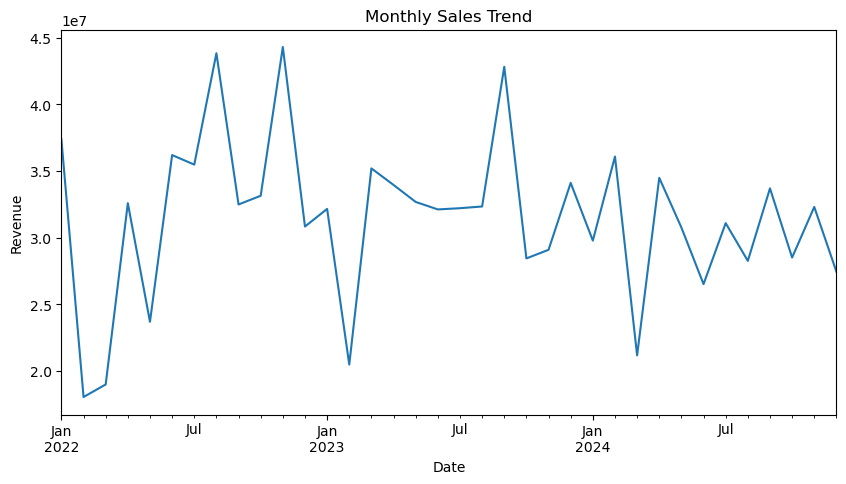

In [3]:
monthly_sales = df.groupby("date")["revenue"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()


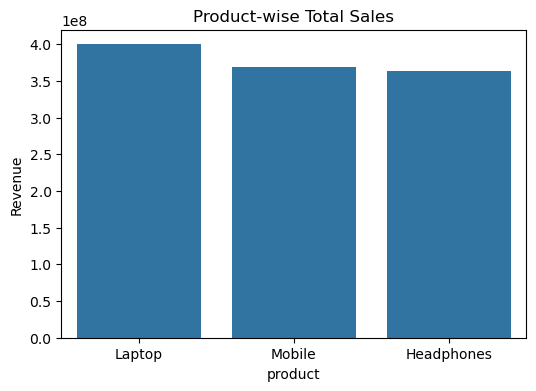

In [4]:
product_sales = df.groupby("product")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=product_sales.index, y=product_sales.values)
plt.title("Product-wise Total Sales")
plt.ylabel("Revenue")
plt.show()


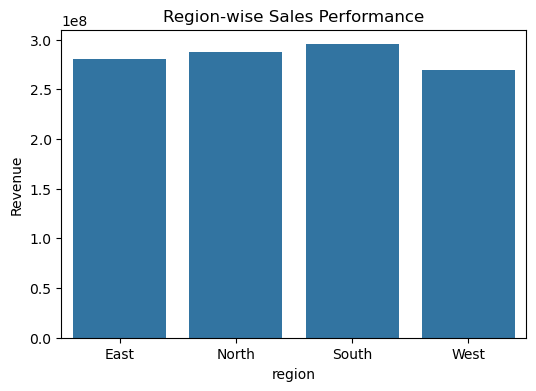

In [5]:
region_sales = df.groupby("region")["revenue"].sum()

plt.figure(figsize=(6,4))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Region-wise Sales Performance")
plt.ylabel("Revenue")
plt.show()


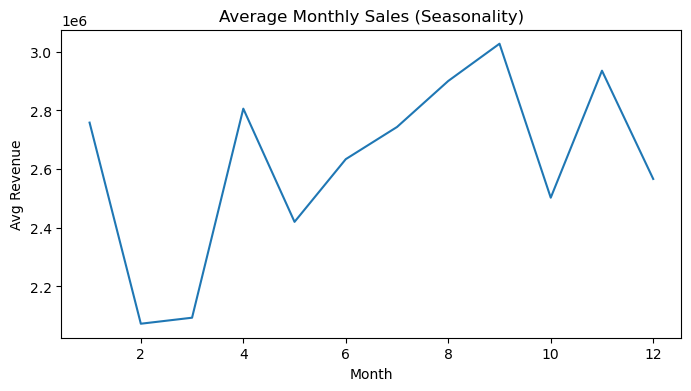

In [6]:
df["month"] = df["date"].dt.month
seasonal_sales = df.groupby("month")["revenue"].mean()

plt.figure(figsize=(8,4))
sns.lineplot(x=seasonal_sales.index, y=seasonal_sales.values)
plt.title("Average Monthly Sales (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Revenue")
plt.show()
